# 图像梯度
- Sobel
- Scharr
- 拉普拉斯
- Canny

卷积核可视化：https://setosa.io/ev/image-kernels/

In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt

## 图像梯度
通过对图像梯度的操作，可以发现图像的边缘信息<br/>
在 OpenCV 中提供了三种类型的滤波器，常见处理方式：Sobel、Scharr 以及 Laplacian 算子

In [2]:
# 加载灰度图
img = cv.imread("./images/small2.png", 0)

# 高斯平滑
# (5, 5)：核大小
# 0：自动计算标准差
# blur = cv.GaussianBlur(img, (5, 5), 0)
blur = cv.GaussianBlur(img, (9, 9), 0)  # 核越大，越平滑

print("原图中的一行：\n", img[11], sep="")
print("\n高斯平滑后图像中的一行：\n", blur[11], sep="")

原图中的一行：
[255 255 255 255 255 255 255 255 255 255  75  71  67  62  56  50  43  42
  49  56  63  52  40  28  22  18  15  14  20  25  30  25  19  13  10  10
  10  21  54  88 255 255 255 255 255 255 255 255 255 255 255]

高斯平滑后图像中的一行：
[255 255 255 255 255 255 252 243 222 185 141 103  78  64  56  51  49  48
  50  52  51  47  40  32  25  21  18  18  20  22  23  22  19  16  14  16
  26  47  83 132 183 222 243 252 255 255 255 255 255 255 255]


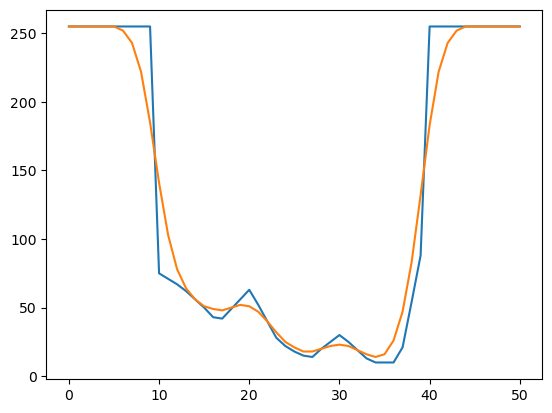

In [3]:
# 绘制像素值曲线
plt.plot(img[11])  # 原图索引为 11 的行
plt.plot(blur[11])  # 高斯模糊后图像

### Sobel
Sobel 滤波器通过加入高斯平滑以及方向导数，抗噪性比较强。

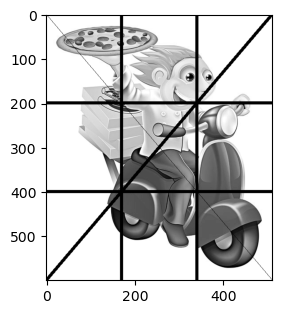

True

In [4]:
# 加载灰度图
img = cv.imread("./images/xiaoren.png", 0)

# 画几条线
rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(0, 0), pt2=(cols, rows), color=0, thickness=1)
cv.line(img, pt1=(cols, 0), pt2=(0, rows), color=0, thickness=5)

plt.subplot(121)
plt.imshow(img, cmap='gray')
plt.show()

# 可视化
# cv.imshow("img", img)
# cv.waitKey(0)
# cv.destroyAllWindows()

# 保存图像
cv.imwrite("./images/xiaoren_tmp.png", img)

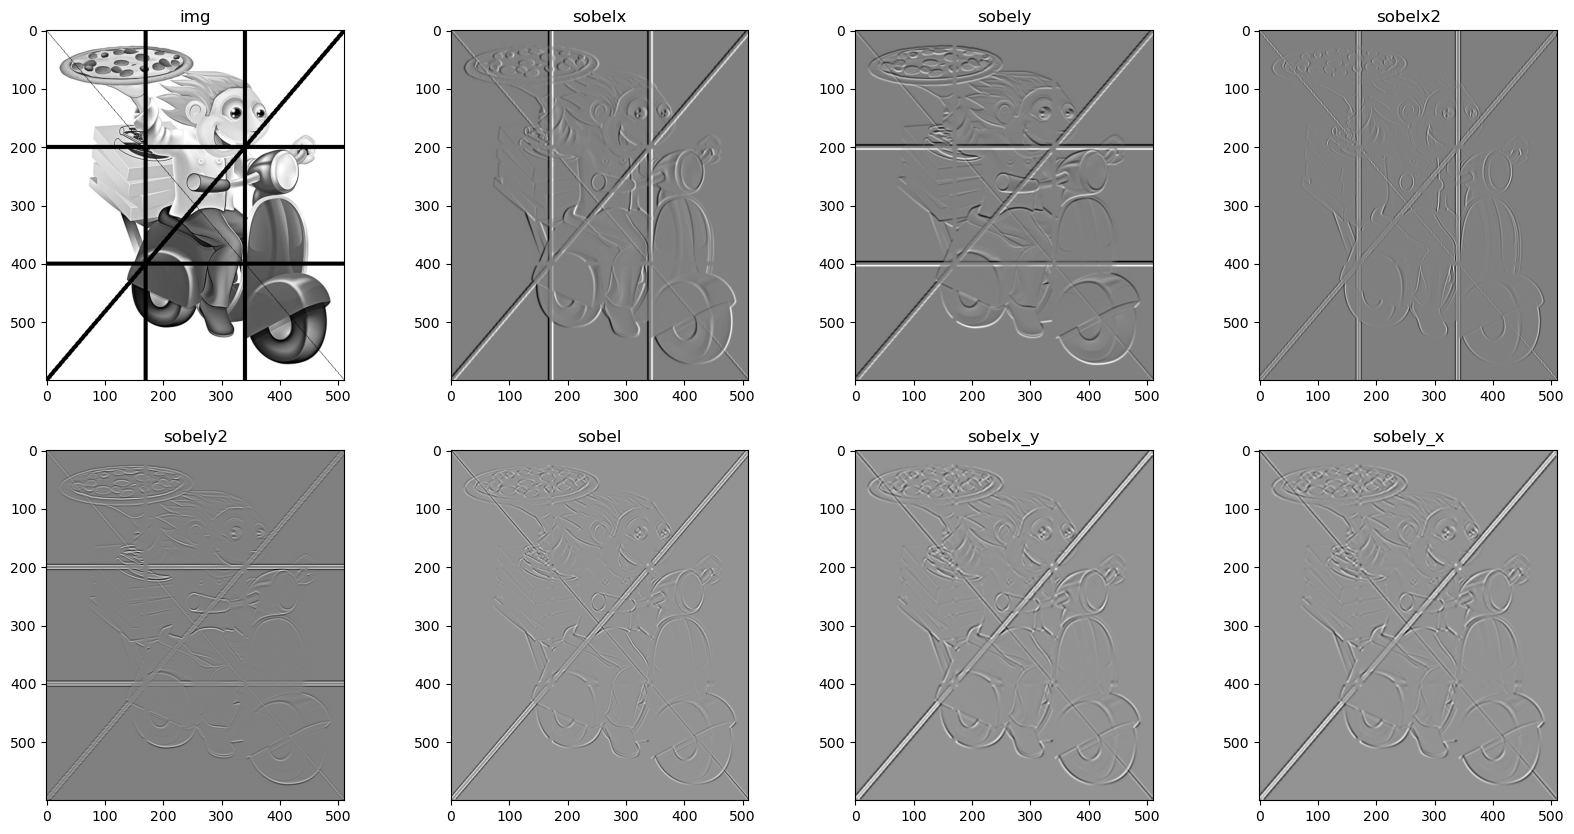

In [9]:
# x方向的的 Sobel 过滤，ksize：一般取值为 3, 5, 7；
# ddepth=6: 输出图像的深度（数据类型），6对应 CV_64F（推荐后者），即 64 位浮点数
# dx=1: 计算 x 方向的一阶导数
# dy=0: 不计算 y 方向的导数
sobelx = cv.Sobel(img, ddepth=6, dx=1, dy=0, ksize=5)  # 提取边缘信息（垂直）
sobely = cv.Sobel(img, cv.CV_64F, dx=0, dy=1, ksize=5)  # 提取边缘信息（水平）

# dx=2：计算 x 方向的二阶导数（即边缘的曲率变化）
sobelx2 = cv.Sobel(img, cv.CV_64F, dx=2, dy=0, ksize=5)  # 提取尖锐的边缘信息（垂直）
sobely2 = cv.Sobel(img, cv.CV_64F, dx=0, dy=2, ksize=5)  # 提取尖锐的边缘信息（水平）

# dx=1, dy=1：计算在 x 和 y 方向的一阶导数（联合梯度）
sobel = cv.Sobel(img, cv.CV_64F, dx=1, dy=1, ksize=5)  # 提取对角线方向的边缘（如斜线、角点）

# 在计算的 x 方向梯度的基础上，进一步计算 y 方向的梯度
sobelx_y = cv.Sobel(sobelx, cv.CV_64F, dx=0, dy=1, ksize=5)  # 提取 sobelx 图像中的水平边缘
sobely_x = cv.Sobel(sobely, cv.CV_64F, dx=1, dy=0, ksize=5)  # 提取 sobely 图像中的垂直边缘

# c. 可视化
plt.figure(figsize=(20, 10))

plt.subplot(241)
plt.imshow(img, 'gray')
plt.title('img')

plt.subplot(242)
plt.imshow(sobelx, 'gray')  # 垂直
plt.title('sobelx')

plt.subplot(243)
plt.imshow(sobely, 'gray')  # 水平
plt.title('sobely')

plt.subplot(244)
plt.imshow(sobelx2, 'gray')  # 垂直（更尖锐）
plt.title('sobelx2')

plt.subplot(245)
plt.imshow(sobely2, 'gray')  # 水平（更尖锐）
plt.title('sobely2')

plt.subplot(246)
plt.imshow(sobel, 'gray')  # 多方向
plt.title('sobel')

plt.subplot(247)
plt.imshow(sobelx_y, 'gray')  # 先垂直再水平
plt.title('sobelx_y')

plt.subplot(248)
plt.imshow(sobely_x, 'gray')  # 先水平再垂直
plt.title('sobely_x')

plt.show()

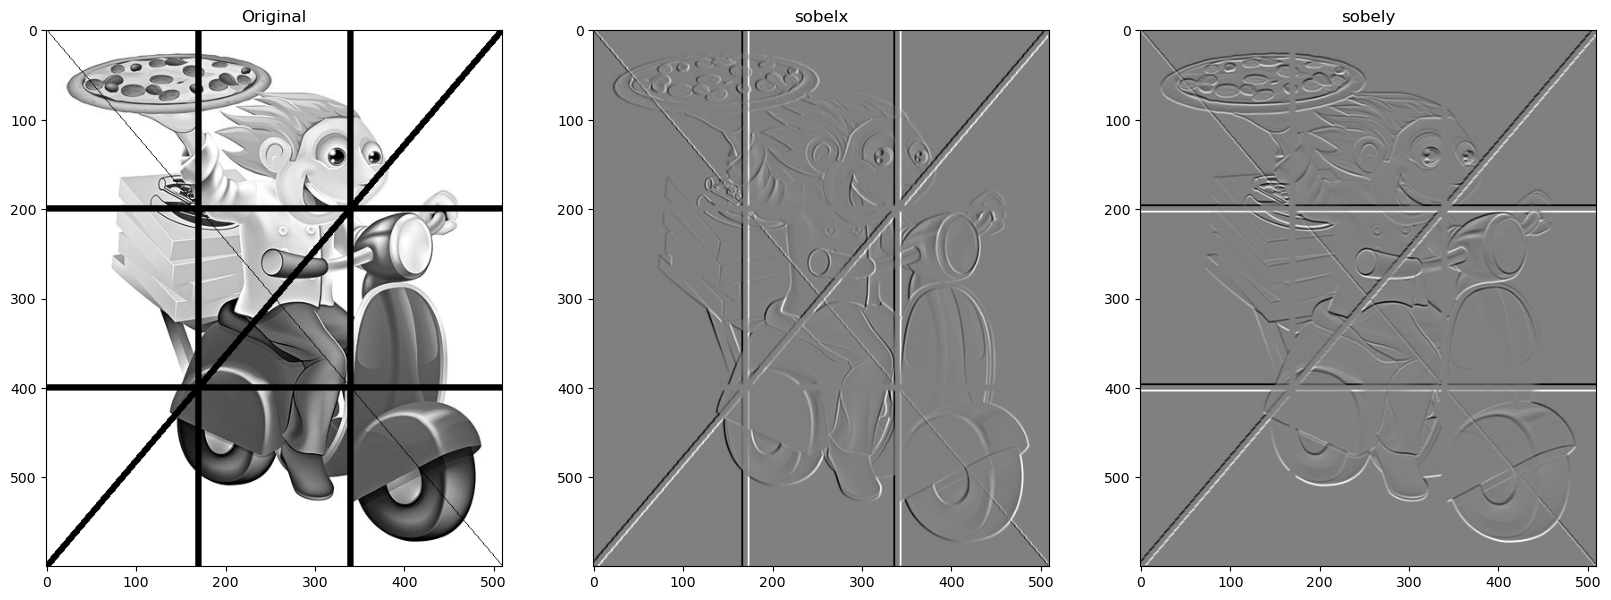

In [6]:
# 自定义一个 kernel 核
kernel = np.asarray([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])
# 做卷积操作
# 第 2 个参数为：ddepth，输出图像深度
sobely = cv.filter2D(img, cv.CV_64F, kernel)  # 提取水平的边缘信息
sobelx = cv.filter2D(img, cv.CV_64F, kernel.T)  # 提取垂直的边缘信息

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(131)
plt.imshow(img, 'gray')
plt.title('Original')

plt.subplot(132)
plt.imshow(sobelx, 'gray')  # 垂直
plt.title('sobelx')

plt.subplot(133)
plt.imshow(sobely, 'gray')  # 水平
plt.title('sobely')
plt.show()

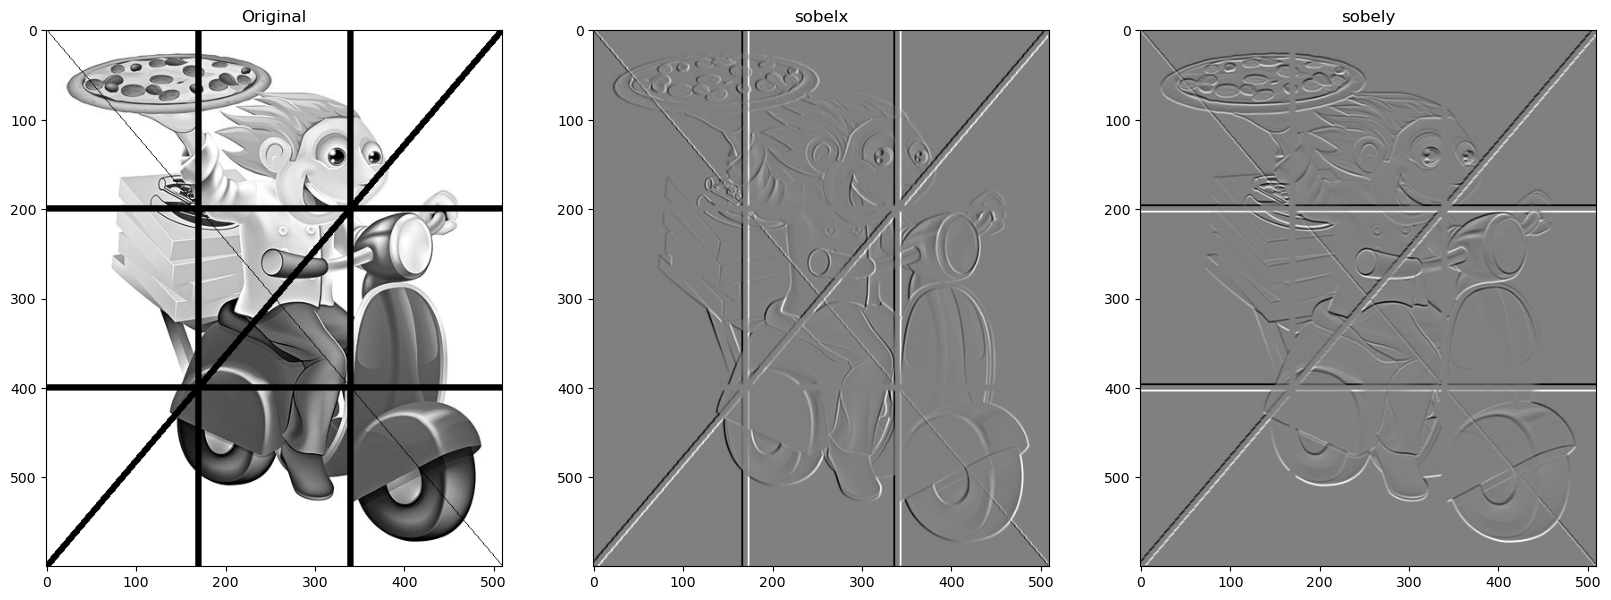

In [7]:
# 自定义一个 kernel 核
kernel = np.asarray([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
])
kernel1 = np.asarray([[1, 2, 1]])  # 水平
kernel2 = np.asarray([[-1],
                      [0],
                      [1]])  # 垂直

# 提取垂直的边缘信息
# 做卷积操作
# sobelx = cv.filter2D(img, cv.CV_64F, kernel.T)      # 等价于下面 2 行
img_blur = cv.filter2D(img, cv.CV_64F, kernel1.T)  # 垂直高斯平滑
sobelx = cv.filter2D(img_blur, cv.CV_64F, kernel2.T)  # 水平梯度

# 提取水平的边缘信息
# sobely = cv.filter2D(img, cv.CV_64F, kernel)      # 等价于下面 2 行
img_blur = cv.filter2D(img, cv.CV_64F, kernel1)  # 水平高斯平滑
sobely = cv.filter2D(img_blur, cv.CV_64F, kernel2)  # 垂直梯度

# 可视化
plt.figure(figsize=(20, 10))
plt.subplot(131)
plt.imshow(img, 'gray')
plt.title('Original')

plt.subplot(132)
plt.imshow(sobelx, 'gray')  # 垂直
plt.title('sobelx')

plt.subplot(133)
plt.imshow(sobely, 'gray')  # 水平
plt.title('sobely')
plt.show()

### Scharr
Scharr可以认为是一种特殊的 Sobel 方式，实际上就是一种特殊的 kernel（固定 3×3），对边缘的响应更强、更精确。

In [4]:
# 加载灰度图
img = cv.imread('./images/xiaoren.png', 0)

# 画几条线
rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
print()

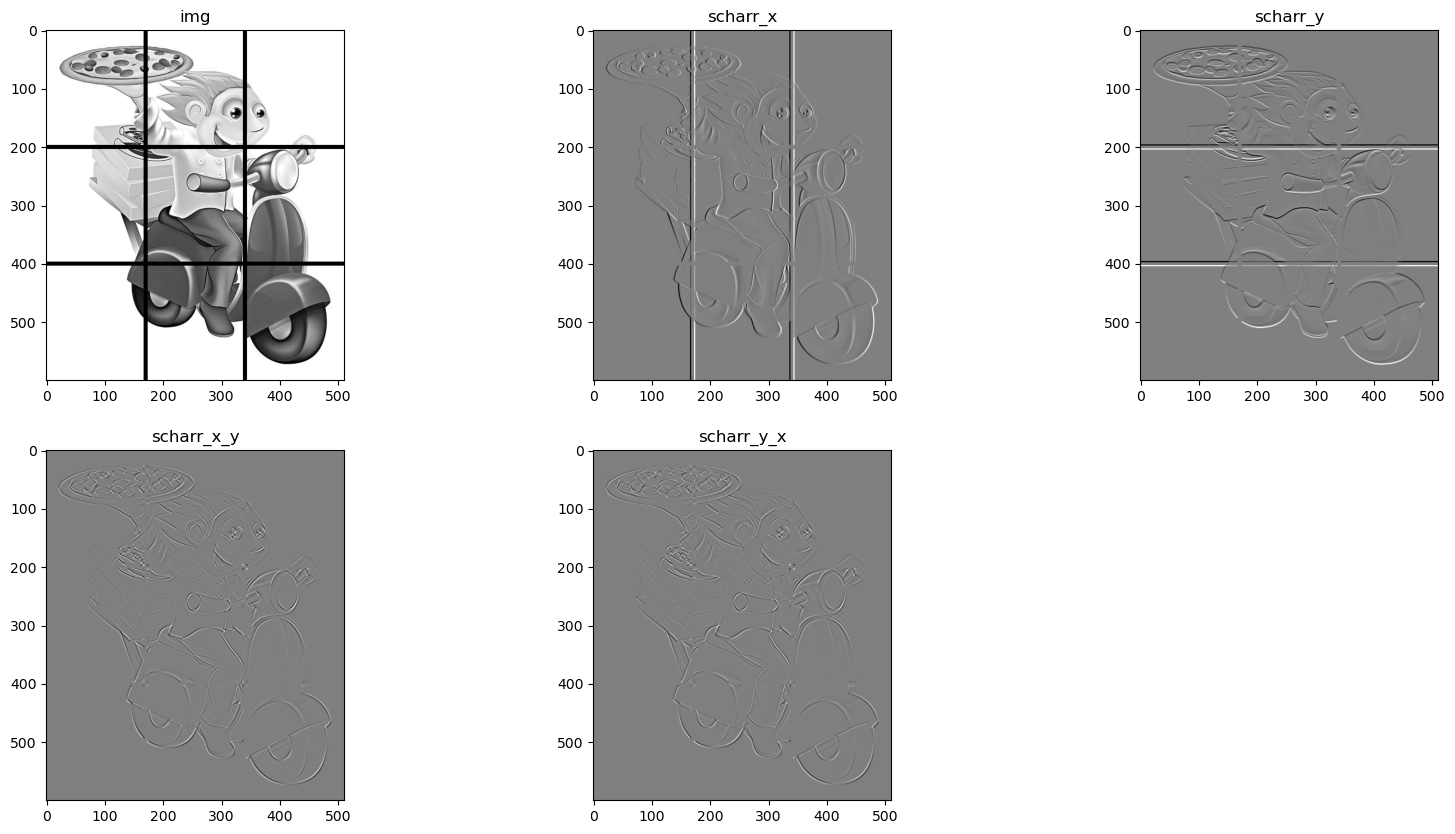

In [9]:
# Scharr中，dx 和 dy 必须有一个为 0，一个为 1
scharr_x = cv.Scharr(img, cv.CV_64F, dx=1, dy=0)  # 提取边缘信息（垂直）
scharr_y = cv.Scharr(img, cv.CV_64F, dx=0, dy=1)  # 提取边缘信息（水平）

# 在计算的 x 方向梯度的基础上，进一步计算 y 方向的梯度
scharr_x_y = cv.Scharr(scharr_x, cv.CV_64F, dx=0, dy=1)  # 提取 scharr_x 图像中的水平边缘
scharr_y_x = cv.Scharr(scharr_y, cv.CV_64F, dx=1, dy=0)  # 提取 scharr_y 图像中的垂直边缘

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(231)
plt.imshow(img, 'gray')
plt.title('img')

plt.subplot(232)
plt.imshow(scharr_x, 'gray')  # 垂直
plt.title('scharr_x')

plt.subplot(233)
plt.imshow(scharr_y, 'gray')  # 水平
plt.title('scharr_y')

plt.subplot(234)
plt.imshow(scharr_x_y, 'gray')  # 先垂直再水平
plt.title('scharr_x_y')

plt.subplot(235)
plt.imshow(scharr_y_x, 'gray')  # 先水平再垂直
plt.title('scharr_y_x')

plt.show()

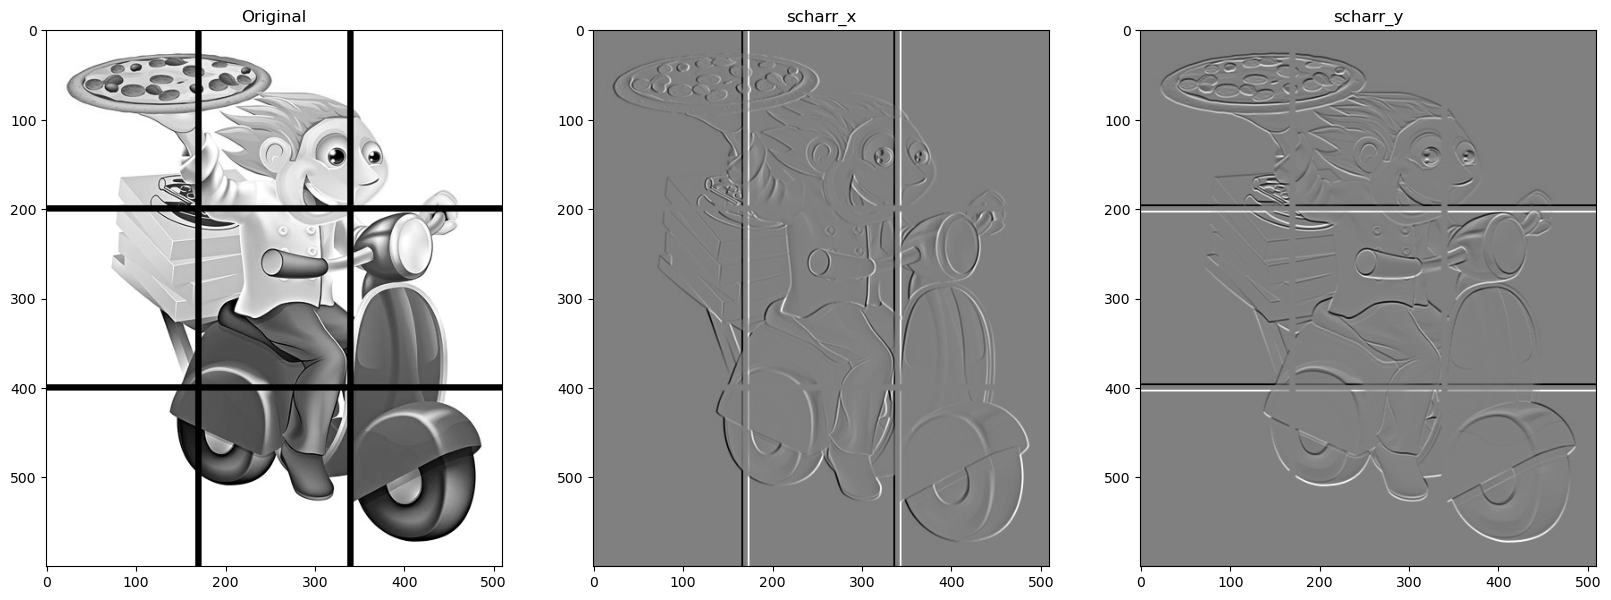

In [10]:
# 自定义一个 kernel 核
kernel = np.asarray([
    [-3, -10, -3],
    [0, 0, 0],
    [3, 10, 3]
])

# 做卷积操作
scharr_y = cv.filter2D(img, cv.CV_64F, kernel)  # 提取水平的边缘信息
scharr_x = cv.filter2D(img, cv.CV_64F, kernel.T)  # 提取垂直的边缘信息

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(131)
plt.imshow(img, 'gray')
plt.title('Original')

plt.subplot(132)
plt.imshow(scharr_x, 'gray')  # 垂直
plt.title('scharr_x')

plt.subplot(133)
plt.imshow(scharr_y, 'gray')  # 水平
plt.title('scharr_y')
plt.show()

### Laplacian
使用拉普拉斯算子进行边缘提取

In [5]:
# 加载灰度图
img = cv.imread('./images/xiaoren.png', 0)

# 画几条线
rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(0, 0), pt2=(cols, rows), color=0, thickness=1)
cv.line(img, pt1=(cols, 0), pt2=(0, rows), color=0, thickness=5)
print()

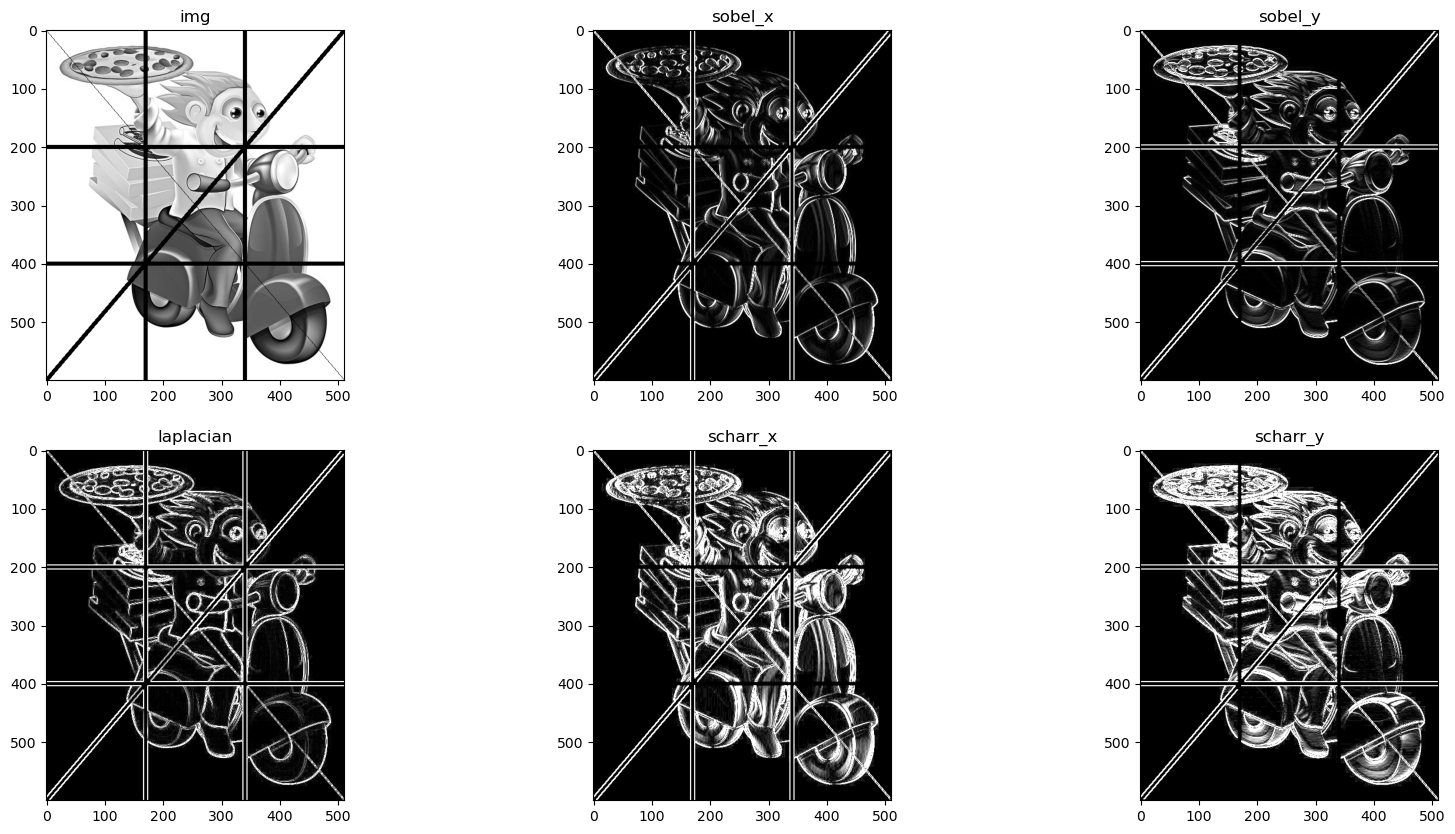

In [6]:
# NOTE: 核中央数字的绝对值 = 周围数字之和，导致可以进行边缘检测
# 因为边缘处卷积值差异较大，非边缘处卷积值相近
# 另外，它不受方向的影响，可以同时检测 x 和 y方向

# 初始化卷积核大小
ksize = 3

# 使用 Laplacian 算子进行边缘检测
laplacian = cv.Laplacian(img, cv.CV_64F, ksize=ksize)
# 将包含正负值的图像转换为一张适合显示和后续处理的 8 位无符号灰度图
# 其中边缘的强度由其绝对值表示
laplacian = cv.convertScaleAbs(laplacian)

sobel_x = cv.Sobel(img, cv.CV_64F, dx=1, dy=0, ksize=ksize)  # 提取边缘信息（垂直）
sobel_x = cv.convertScaleAbs(sobel_x)

sobel_y = cv.Sobel(img, cv.CV_64F, dx=0, dy=1, ksize=ksize)  # 提取边缘信息（水平）
sobel_y = cv.convertScaleAbs(sobel_y)

scharr_x = cv.Scharr(img, cv.CV_64F, dx=1, dy=0)  # 提取边缘信息（垂直）
scharr_x = cv.convertScaleAbs(scharr_x)

scharr_y = cv.Scharr(img, cv.CV_64F, dx=0, dy=1)  # 提取边缘信息（水平）
scharr_y = cv.convertScaleAbs(scharr_y)

# 可视化
plt.figure(figsize=(20, 10))

plt.subplot(231)
plt.imshow(img, 'gray')
plt.title('img')

plt.subplot(232)
plt.imshow(sobel_x, 'gray')  # 垂直
plt.title('sobel_x')

plt.subplot(233)
plt.imshow(sobel_y, 'gray')  # 水平
plt.title('sobel_y')

plt.subplot(234)
plt.imshow(laplacian, 'gray')  # 所有方向
plt.title('laplacian')

plt.subplot(235)
plt.imshow(scharr_x, 'gray')  # 垂直
plt.title('scharr_x')

plt.subplot(236)
plt.imshow(scharr_y, 'gray')  # 水平
plt.title('scharr_y')
plt.show()

在 Sobel 检测中，depth 对于结果的影响：<br/>
当输出的 depth 设置为比较低的数据格式，那么当梯度值计算为负值的时候，就会将其重置为 0，从而导致失真。

在 Laplacian 检测中，该问题不大。

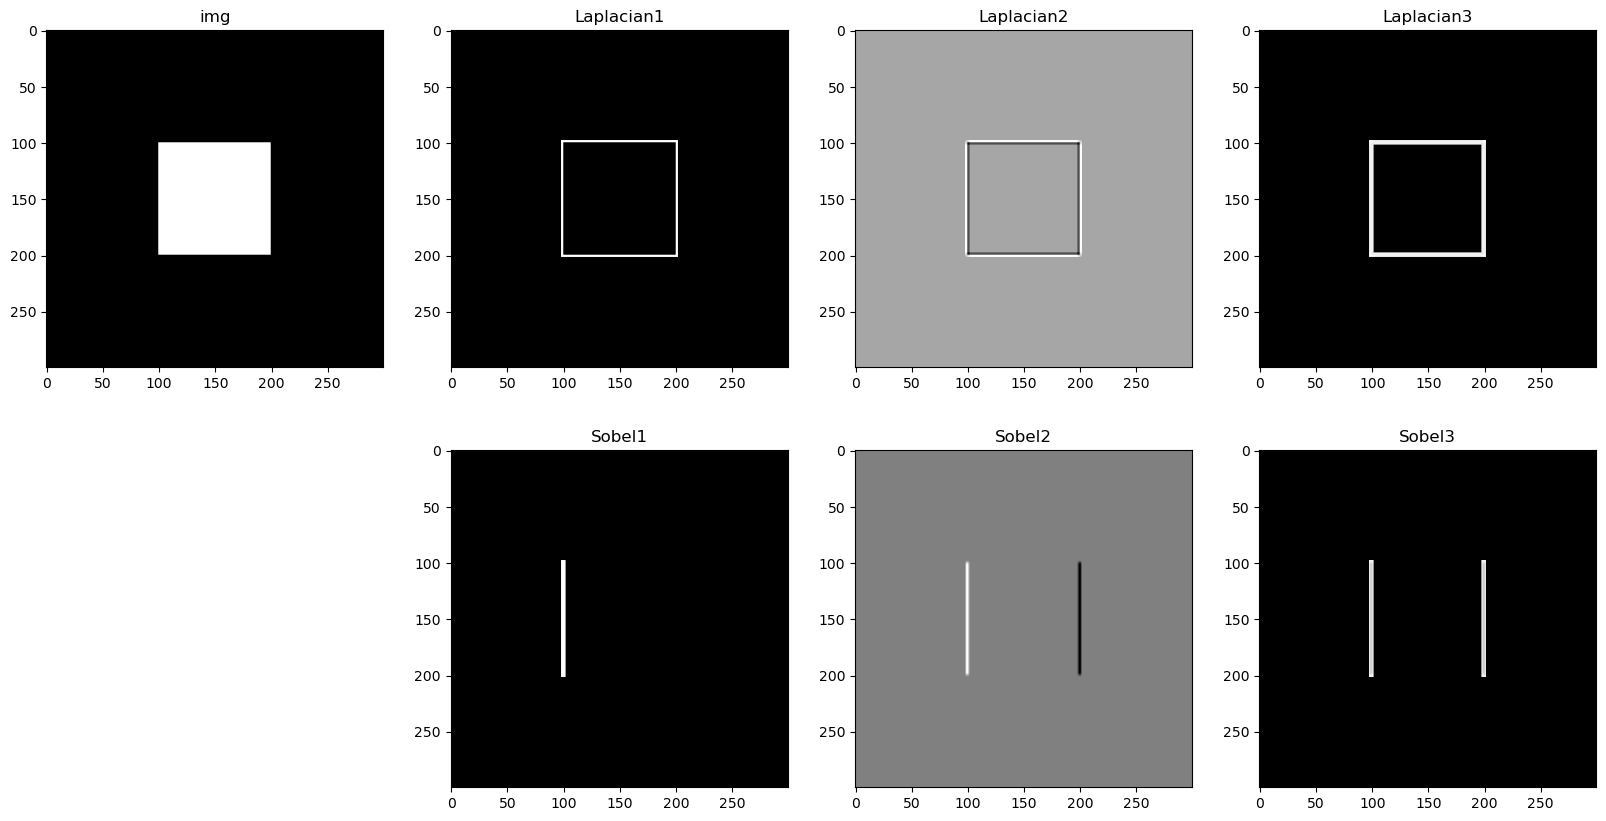

In [8]:
# 构建一个黑色图像
img = np.zeros((300, 300), np.uint8)
# 在黑底上加白框
img[100:200, 100:200] = 255

# 构建白底黑框的图像
# img = np.ones((300, 300), np.uint8) * 255
# img[100:200, 100:200] = 0

ksize = 5  # 初始化卷积核大小

# 使用 Laplacian 算子进行边缘检测
dst1 = cv.Laplacian(img, cv.CV_8U, ksize=ksize)  # 数据格式低
dst2 = cv.Laplacian(img, cv.CV_64F, ksize=ksize)  # 数据格式高
# .absolute()：求绝对值
# .uint8()：转成 8 位无符号灰度图
dst3 = np.uint8(np.absolute(dst2))  # 数据格式低

# 做 Sobel 的操作
dst4 = cv.Sobel(img, cv.CV_8U, dx=1, dy=0, ksize=ksize)  # 数据格式低
dst5 = cv.Sobel(img, cv.CV_64F, dx=1, dy=0, ksize=ksize)  # 数据格式高
dst6 = np.uint8(np.absolute(dst5))  # 数据格式低

# c. 可视化
plt.figure(figsize=(20, 10))

plt.subplot(241)
plt.imshow(img, 'gray')
plt.title('img')

plt.subplot(242)
plt.imshow(dst1, 'gray')  # 低：1 条线
plt.title('Laplacian1')

plt.subplot(243)
plt.imshow(dst2, 'gray')  # 高：2 条线（外边白线，里边黑线）
plt.title('Laplacian2')

plt.subplot(244)
plt.imshow(dst3, 'gray')  # 低：2 条线（求绝对值后，里边黑线变成白线）
plt.title('Laplacian3')

plt.subplot(246)
plt.imshow(dst4, 'gray')  # 低：1 条线（不支持负数，只显示左边 255-0=255 的梯度，不显示右边 0-255=-255 的梯度）
plt.title('Sobel1')

plt.subplot(247)
plt.imshow(dst5, 'gray')  # 高：2 条线（浮点数：左边很大的正数，右边很小的负数，灰色部分都为 0；
# 可视化：很大的正数映射为 255 白色，很小的负数映射为 0 黑色，原有的 0 区域映射为中间值灰色）
plt.title('Sobel2')

plt.subplot(248)
plt.imshow(dst6, 'gray')  # 低：2 条线（求绝对值后，里边黑线变成白线，原有的 0 区域仍然为 0）
plt.title('Sobel3')

plt.show()

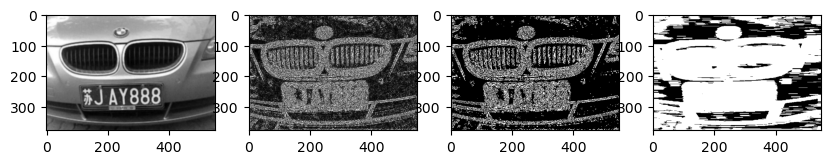

In [5]:
img = cv.imread("./images/car.jpg")  # 加载图像
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # 转灰度图
img = cv.GaussianBlur(img, (5, 5), 2)  # 高斯平滑（2：标准差，控制模糊强度）

img1 = cv.Laplacian(img, cv.CV_64F, ksize=5)  # 使用 Laplacian 算子进行边缘检测
img1 = np.uint8(np.absolute(img1))  # 转成整数

# 二值化处理
ret, img2 = cv.threshold(img1, 127, 255, cv.THRESH_BINARY)

# 膨胀操作（水平）
# iterations=4：操作次数
kernel = np.asarray([
    [1, 1, 1, 1, 1, 1, 1, 1]
])
img3 = cv.dilate(img2, kernel, iterations=4)

fig, axex = plt.subplots(1, 4, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(img1, cmap='gray')
axex[2].imshow(img2, cmap='gray')
axex[3].imshow(img3, cmap='gray')
plt.show()

# cv.imshow('img', img)
# cv.imshow('img1', img1)  # 提取边缘信息
# cv.imshow('img2', img2)  # 二值化
# cv.imshow('img3', img3)  # 膨胀操作（水平）
# cv.waitKey(0)
# cv.destroyAllWindows()

### Canny
Canny算法是一种比 Sobel 和 Laplacian 效果更好的一种边缘检测算法；

在 Canny 算法中，主要包括以下几个阶段：
- Noise Reduction：降噪，使用 5*5 的 kernel 做 Gaussian filter 降噪；
- Finding Intensity Gradient of the Image：求图像像素的梯度值；
- Non-maximum Suppression：删除可能不构成边缘的像素，即在渐变方向上相邻区域的像素梯度值是否是最大值，如果不是，则进行删除；
- NOTE: NMS 非极大值抑制，直白来讲就是在边缘位置只需要保留少量的像素点即可；
- Hysteresis Thresholding：基于阈值来判断是否属于边；大于 maxval 的一定属于边，小于 minval 的一定不属于边，在这个中间的可能属于边的边缘；
- NOTE：双边阈值，直白来讲就是用来选择真的属于边缘的像素，针对可能异常的信息，直接丢弃；
<br/>

参考页面：
- https://en.wikipedia.org/wiki/Canny_edge_detector

In [10]:
# 加载灰度图
img = cv.imread('./images/xiaoren.png', 0)

# 画几条线
rows, cols = img.shape
cv.line(img, pt1=(0, rows // 3), pt2=(cols, rows // 3), color=0, thickness=5)
cv.line(img, pt1=(0, 2 * rows // 3), pt2=(cols, 2 * rows // 3), color=0, thickness=5)
cv.line(img, pt1=(cols // 3, 0), pt2=(cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(2 * cols // 3, 0), pt2=(2 * cols // 3, rows), color=0, thickness=5)
cv.line(img, pt1=(0, 0), pt2=(cols, rows), color=0, thickness=1)
cv.line(img, pt1=(cols, 0), pt2=(0, rows), color=0, thickness=5)
print()

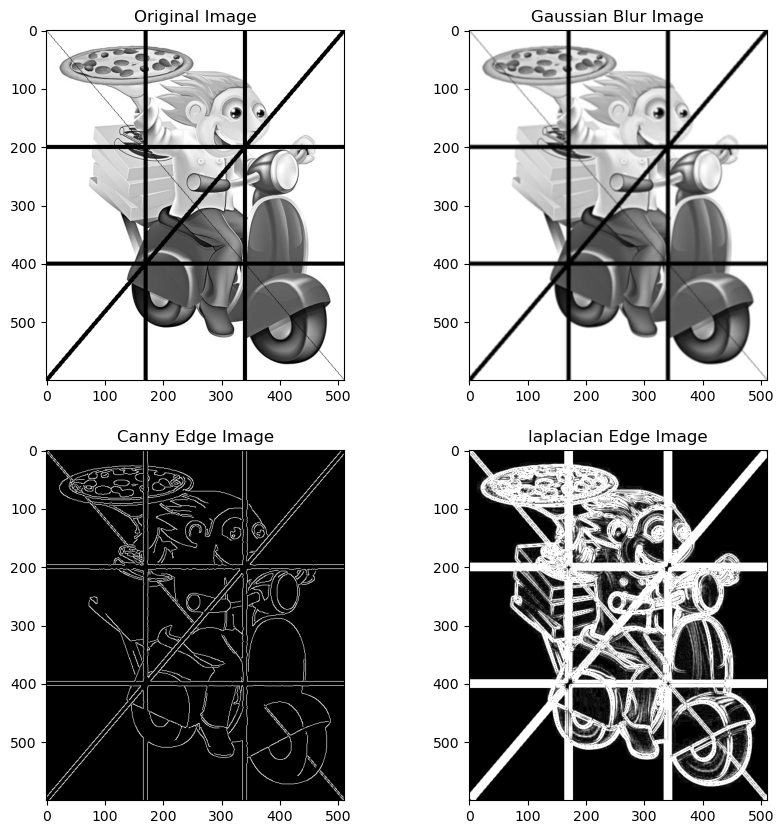

In [11]:
"""做一个 Canny 边缘检测 (OpenCV 中是不包含高斯去噪的)"""

# a. 高斯去噪
# 0：会根据核大小自动计算标准差
blur = cv.GaussianBlur(img, (5, 5), 0)

# b. Canny边缘检测
# threshold1=50：低阈值，梯度值低于此阈值的边缘被丢弃
# threshold2=250：高阈值，梯度值高于此阈值的边缘被保留为强边缘
edges = cv.Canny(blur, threshold1=50, threshold2=250)

# 使用 Laplacian 算子进行边缘检测
laplacian = cv.Laplacian(blur, cv.CV_64F, ksize=5)
# 通过取绝对值和类型转换生成可视化的边缘图
laplacian = cv.convertScaleAbs(laplacian)

# 可视化
plt.figure(figsize=(10, 10))

plt.subplot(221)
plt.imshow(img, cmap='gray')
plt.title('Original Image')

plt.subplot(222)
plt.imshow(blur, cmap='gray')  # 高斯去噪
plt.title('Gaussian Blur Image')

plt.subplot(223)
plt.imshow(edges, cmap='gray')  # Canny 边缘检测
plt.title('Canny Edge Image')

plt.subplot(224)
plt.imshow(laplacian, cmap='gray')  # laplacian 边缘检测
plt.title('laplacian Edge Image')
plt.show()

In [12]:
# 将灰度图转成 BGR 格式
bgr_xiaoren = cv.cvtColor(edges, cv.COLOR_GRAY2BGR)
# 画矩形
cv.rectangle(bgr_xiaoren, pt1=(243, 243), pt2=(253, 253), color=(0, 0, 255), thickness=2)
# 可视化
cv.imshow("image", bgr_xiaoren)

cv.waitKey(0)
# 释放指定窗口资源
cv.destroyWindow('image')

In [16]:
blur[243:253, 243:253]  # 高斯模糊

array([[188, 190, 192, 194, 197, 201, 204, 206, 207, 208],
       [188, 190, 192, 195, 198, 200, 199, 194, 189, 185],
       [189, 191, 193, 195, 191, 180, 165, 150, 138, 133],
       [190, 192, 191, 181, 159, 134, 113, 100,  94,  94],
       [191, 189, 174, 144, 113,  93,  88,  91,  96, 103],
       [188, 171, 138, 104,  89,  92, 104, 116, 126, 132],
       [173, 138, 104,  91, 100, 116, 130, 140, 146, 150],
       [146, 108,  93, 106, 125, 139, 146, 151, 154, 156],
       [119,  96, 106, 128, 144, 151, 155, 157, 160, 162],
       [104, 104, 128, 146, 154, 158, 161, 163, 165, 167]], dtype=uint8)

In [17]:
edges[243:253, 243:253]  # Canny边缘检测（二值化）

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [  0,   0,   0,   0,   0,   0, 255, 255, 255, 255],
       [  0,   0,   0,   0, 255, 255,   0,   0,   0,   0],
       [  0,   0, 255, 255, 255,   0,   0,   0,   0,   0],
       [  0, 255, 255,   0,   0,   0,   0,   0,   0,   0],
       [255, 255,   0,   0,   0,   0,   0,   0,   0,   0],
       [255,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [255,   0,   0, 255,   0,   0,   0,   0,   0,   0],
       [  0,   0, 255, 255,   0,   0,   0,   0,   0,   0]], dtype=uint8)

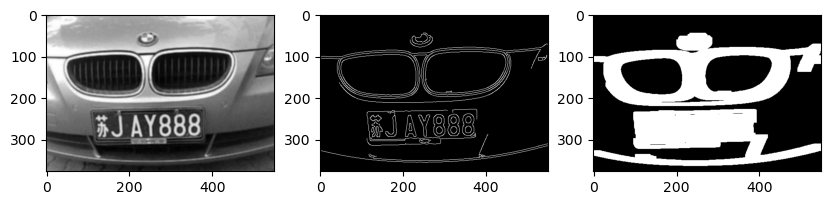

In [6]:
"""车牌边缘检测"""

img = cv.imread("./images/car.jpg")  # 加载图像
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)  # 转灰度图
img = cv.GaussianBlur(img, (5, 5), 2)  # 高斯去噪，标准差为 2

# 提取图像边缘（二值化图）
# threshold1=50：低阈值，梯度值低于此阈值的边缘被丢弃
# threshold2=250：高阈值，梯度值高于此阈值的边缘被保留为强边缘（输出为白色）
img1 = cv.Canny(img, threshold1=50, threshold2=250)

# 膨胀操作
# 形状：(2, 5)，垂直方向膨胀少点，水平方向膨胀多点
kernel = np.asarray([
    [1, 1, 1, 1, 1],
    [1, 1, 1, 1, 1]
])
img2 = cv.dilate(img1, kernel, iterations=8)

fig, axex = plt.subplots(1, 3, figsize=(10, 8), dpi=100)
axex[0].imshow(img, cmap='gray')
axex[1].imshow(img1, cmap='gray')
axex[2].imshow(img2, cmap='gray')
plt.show()

# cv.imshow('img', img)
# cv.imshow('img1', img1)  # 提取图像边缘
# cv.imshow('img2', img2)  # 膨胀后图像
# cv.waitKey(0)
# cv.destroyAllWindows()